# Topic 1 · Regression and uncertainty on The Geysers

**What does injection do to the seismicity of The Geysers, what is its *b*-value — and how well do
you know either answer?**

This is the homework notebook for topic 1. The taught notebook, `01_regression_uncertainty.ipynb`,
built least squares, its error bars, ridge and maximum likelihood on synthetic data, where the truth
is known; the section numbers A.1 to A.8 below refer to it. Here the same tools meet field data, where
the truth is not known, and each result is set against an independent record instead. Three questions:

1. **Part B.** How much of the monthly earthquake rate does the injection record account for, once the
   fit is given the columns it needs, and does the annual injection cycle appear in the rate?
2. **Part C.** Is the *b*-value different when injection is rising from when it is falling, and would a
   difference of the published size be resolvable in this catalogue?
3. **Both parts.** How much wider is each interval once the independence it assumes is dropped?

The two papers, and what each does here:

- **Trugman et al. (2016)**, *JGR: Solid Earth*, `10.1002/2015jb012510` — find the background
  seismicity rate at The Geysers highly correlated with injection, with strong seasonal fluctuations
  after the Santa Rosa pipeline of 2003, and significant temporal variations in the *b*-value. Part B
  tests the seasonal cycle on field-wide monthly totals; Part C measures how far *b* moves from year to
  year.
- **Leptokaropoulos & Staszek (2018)**, *Acta Geophysica*, `10.1007/s11600-018-0215-1` — a *b*-value
  of 1.18 ± 0.06 under increasing injection against 1.10 ± 0.05 under decreasing injection, in the
  northwest of the field. Part C plants a difference of that size in the field-wide catalogue, recovers
  it, and then asks whether one is there.

**The data.** Two release assets, read through the course's `geysers_data` module: the NCEDC routine
catalogue for the region (earthquakes only, placeholder magnitudes removed), cut to the producing-field
window −122.99 to −122.65 °E and 38.70 to 38.899 °N; and CalGEM's monthly field totals of steam
production and water injection. Both parts use the months from 1981 to 2025.


In [1]:
# ── Checkpoint 1 ── run this first: it is all this notebook needs, without the taught one ──
import importlib.util
import subprocess
import sys
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

missing = [pkg for pkg in ("numpy", "pandas", "matplotlib", "requests") if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

# The course's data modules. On DataHub they sit beside the notebook; Colab opens the notebook alone,
# so they are fetched every run there, because a Colab runtime can outlive a stale copy.
BASE = "https://raw.githubusercontent.com/AI4EPS/EPS207_Observational_Seismology/main/docs/notebooks"
if "google.colab" in sys.modules or importlib.util.find_spec("geysers_data") is None:
    for module in ("geysers_data.py", "geysers_func.py", "geysers_plot.py"):
        for attempt in range(4):             # eight people fetch these in the same two minutes
            try:
                urllib.request.urlretrieve(f"{BASE}/{module}", module)
                break
            except Exception as exc:
                if attempt == 3:
                    raise RuntimeError(f"could not fetch {module}: {exc}; re-run this cell") from None
                time.sleep(2 * (attempt + 1))
    for name in ("geysers_data", "geysers_func", "geysers_plot"):
        sys.modules.pop(name, None)

rng = np.random.default_rng(207)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
print("seed 207; the data are two release assets, read through geysers_data.catalog() and production()")


seed 207; the data are two release assets, read through geysers_data.catalog() and production()


## Part B · The seismicity rate and the injection record

From here the data are The Geysers, and the truth is gone. Nobody knows how many earthquakes a
megatonne of injected water produces, so no interval computed below can be compared with the value it
claims to contain, as those of the taught notebook's Part A could be. What takes the place of the truth is an **independent record**:
CalGEM's monthly field totals of injection and production, which the seismic network played no part
in making. The question is how much of the catalogue's monthly rate that record accounts for, and
what survives when the fit is given the columns it needs.

The question has been answered both ways. Eberhart-Phillips & Oppenheimer (1984) cross-correlated
monthly earthquake counts with injection for the wells they studied, over 1975–1982, and found no
consistent pattern of correlation; Trugman et al. (2016, `10.1002/2015jb012510`) find the background
rate highly correlated with injection, with strong seasonal fluctuations after the Santa Rosa
pipeline of 2003.

| from Part A of the taught notebook | used here |
|---|---|
| A.1 a model is a design matrix | B.2, B.3 |
| A.4 the standard error is the inverse curvature | B.2–B.4 |
| A.6 columns that move together trade their coefficients | B.3 |
| A.3 the likelihood assumes **independent** errors | B.5 |

**What the record can and cannot resolve.** Both series are **field-wide monthly totals** (§ 2.6 of
the project notebook), so nothing about an individual well, or about any process faster than a month,
can be asked of them. The months used are 1981 to 2025; Part C measures the catalogue's completeness
over exactly those years.


### B.1 · Two records on one grid

Monthly water injection and steam production for the whole field, from CalGEM, against monthly
counts of catalogue earthquakes in the field window at two thresholds. M ≥ 1.2 is the threshold
§ 10.2 of the project notebook uses. M ≥ 2.5 selects events that the regional network was already
detecting before the borehole network arrived (§ 4.7), so a change in detection cannot produce a
change in that count.


In [2]:
# ── Checkpoint 2 ── Part B starts from the release assets: after the setup cell, rejoin here ──
import pandas as pd
from geysers_data import catalog, production, FIELD   # beside the notebook; the setup cell fetched it on Colab

cat = catalog()                       # earthquakes only, placeholder magnitudes removed
field = cat[cat.longitude.between(FIELD[0], FIELD[1])
            & cat.latitude.between(FIELD[2], FIELD[3])].sort_values("time")
prod = production()                   # CalGEM monthly field totals, in megatonnes

edges = pd.date_range(prod.index[0], prod.index[-1] + pd.offsets.MonthBegin(1), freq="MS")
t_event = field.time.dt.tz_localize(None)
d = prod[["production", "injection"]].copy()
d["n"] = np.histogram(t_event[field.mag >= 1.2], bins=edges)[0]
d["n25"] = np.histogram(t_event[field.mag >= 2.5], bins=edges)[0]
d = d.loc["1981":"2025"].dropna()
assert len(d) > 500 and (d.injection > 0).all() and d.n.sum() > 0, \
    "the two assets did not load as expected -- re-run the setup cell, then this one"

print(f"field window {FIELD} (lon W, lon E, lat S, lat N)")
print(f"catalogue: {len(field):,} earthquakes, {field.time.min():%Y-%m} to {field.time.max():%Y-%m}")
print(f"CalGEM: {prod.index[0]:%Y-%m} to {prod.index[-1]:%Y-%m}")
print(f"{len(d)} months used, {d.index[0]:%Y-%m} to {d.index[-1]:%Y-%m}")
print(f"earthquakes per month, M >= 1.2: median {d.n.median():.0f}, max {d.n.max():.0f}")
print(f"earthquakes per month, M >= 2.5: median {d.n25.median():.0f}, max {d.n25.max():.0f}")


field window [-122.99, -122.65, 38.7, 38.899] (lon W, lon E, lat S, lat N)
catalogue: 403,475 earthquakes, 1972-03 to 2025-12
CalGEM: 1969-01 to 2026-07
540 months used, 1981-01 to 2025-12
earthquakes per month, M >= 1.2: median 149, max 437
earthquakes per month, M >= 2.5: median 6, max 19


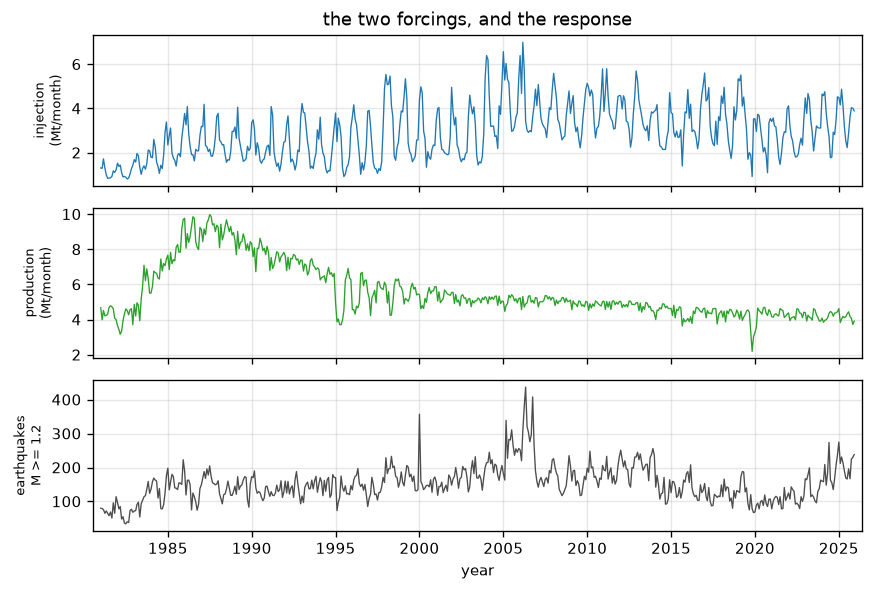

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(7.4, 5.0), sharex=True)
axs[0].plot(d.index, d.injection, lw=0.8, color="C0")
axs[0].set_ylabel("injection\n(Mt/month)", fontsize=8)
axs[1].plot(d.index, d.production, lw=0.8, color="C2")
axs[1].set_ylabel("production\n(Mt/month)", fontsize=8)
axs[2].plot(d.index, d.n, lw=0.8, color="0.3")
axs[2].set_ylabel("earthquakes\nM >= 1.2", fontsize=8)
axs[2].set_xlabel("year")
for a_ in axs:
    a_.margins(x=0.01)
axs[0].set_title("the two forcings, and the response")
fig.tight_layout(); plt.show()


### B.2 · The same regression, twice

One predictor, one response, and A.1's design matrix: $n = c_0 + c_1 x$, where $x$ is the month's
injection or its production, in megatonnes. The two slopes are in the same units, but they are
compared here through what A.4 provides, each against **its own standard error**.


In [4]:
def fit(columns, y):
    """Least squares with A.4's covariance. Returns coefficients, standard errors, R^2, residuals."""
    X = np.column_stack([np.ones(len(y))] + list(columns))
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    r = y - X @ b
    C = (r @ r / (len(y) - X.shape[1])) * np.linalg.inv(X.T @ X)
    return b, np.sqrt(np.diag(C)), 1 - (r @ r) / ((y - y.mean()) ** 2).sum(), r


y_b = d.n.values.astype(float)
inj, stm = d.injection.values, d.production.values

print(f"{'predictor':>12s} {'slope (eq per Mt)':>19s} {'slope / se':>11s} {'R^2':>6s}")
for name, x in (("injection", inj), ("production", stm)):
    b, se, r2, _ = fit([x], y_b)
    print(f"{name:>12s} {b[1]:10.2f} +/-{se[1]:5.2f} {b[1] / se[1]:11.1f} {r2:6.3f}")


   predictor   slope (eq per Mt)  slope / se    R^2
   injection      22.40 +/- 1.59        14.1  0.270
  production      -0.54 +/- 1.49        -0.4  0.000


Taken alone, the two fits make a contrast: the injection slope is many standard errors from zero and
the production slope is within one of it. Both predictors trend across the record, as the figure
above shows. A.2 showed that whatever a fit has no column for is left in its residual; the next section
asks what a slope does when that missing column moves with its predictor.


### B.3 · One term at a time: the column both fits left out

Add calendar time as a column, first beside each forcing and then beside both, and watch what each
slope does. The variance inflation factor of A.6, $1/(1-R_j^2)$, says how far each column of the
largest model is predictable from the other two.


In [5]:
years = (d.index.year + (d.index.month - 1) / 12).values      # calendar time, in years
for name, x in (("injection", inj), ("production", stm), ("earthquakes", y_b)):
    print(f"correlation of {name:>11s} with calendar time: {np.corrcoef(x, years)[0, 1]:+.2f}")

models = (("production", {"production": stm}),
          ("production + time", {"production": stm, "time": years}),
          ("injection + time", {"injection": inj, "time": years}),
          ("injection + production + time", {"injection": inj, "production": stm, "time": years}))
print(f"\n{'columns':>30s} {'injection':>17s} {'production':>17s} {'time (eq/yr)':>17s}")
for label, cols in models:
    b, se, _, _ = fit(cols.values(), y_b)
    cell = {k: f"{b[i + 1]:7.2f} ({b[i + 1] / se[i + 1]:+5.1f} se)" for i, k in enumerate(cols)}
    print(f"{label:>30s} " + " ".join(f"{cell.get(k, '-'):>17s}"
                                     for k in ("injection", "production", "time")))

three = {"injection": inj, "production": stm, "time": years}
print()
for k, x in three.items():
    others = [v for j, v in three.items() if j != k]
    print(f"VIF of {k:>10s} in the three-column model: {1 / (1 - fit(others, x)[2]):.2f}")


correlation of   injection with calendar time: +0.45
correlation of  production with calendar time: -0.67
correlation of earthquakes with calendar time: +0.19

                       columns         injection        production      time (eq/yr)
                    production                 -   -0.54 ( -0.4 se)                 -
             production + time                 -    7.03 ( +3.6 se)    1.33 ( +5.8 se)
              injection + time   23.36 (+13.2 se)                 -   -0.20 ( -1.2 se)
 injection + production + time   23.08 (+13.1 se)    6.04 ( +3.6 se)    0.28 ( +1.3 se)

VIF of  injection in the three-column model: 1.25
VIF of production in the three-column model: 1.81
VIF of       time in the three-column model: 2.10


With calendar time in the design, the production slope moves from within one standard error of zero
to several, and the injection slope barely moves. The inflation factors are small, so this is not an
error bar widening: the production coefficient itself changed once the column it had been standing in
for was present. The correlations printed first say why: production falls through the record while the
earthquake count rises slightly, so a production column alone was asked to account for a rising count
with a falling predictor, and its slope settled near zero. The contrast of B.2 was a property of the
column those fits omitted.

The time column is not a mechanism. It absorbs whatever changed steadily over four decades, and
nothing in this design can say what that was — which is the objection § 10.3 of the project notebook
raises against any two trending series. What a trend cannot produce is a twelve-month period.


### B.4 · The annual cycle, which a trend cannot imitate

§ 2.5 of the project notebook measured the seasonal component of the forcing: injection swings by
roughly a third about its running mean, production by less than a tenth. Subtracting a thirteen-month
centred running mean from every series removes the trend, and anything else slower than a year, and
leaves the cycle. Regress the seismicity anomaly on both forcing anomalies, at both thresholds.

**This is the independent check the session uses on the field**: the CalGEM record's own annual
cycle, against a catalogue it had no part in making.


In [6]:
a = d.copy()
for c in ("injection", "production", "n", "n25"):
    a[c] = d[c] - d[c].rolling(13, center=True).mean()      # deviation from the running mean
a = a.dropna()
print(f"{len(a)} months after the running mean trims six at each end\n")

print(f"{'response':>9s} {'injection anomaly':>28s} {'production anomaly':>28s} {'R^2':>6s}")
res_a = {}
for label, col in (("M >= 1.2", "n"), ("M >= 2.5", "n25")):
    b, se, r2, r = fit([a.injection.values, a.production.values], a[col].values.astype(float))
    res_a[col] = (b, se, r)
    print(f"{label:>9s} {b[1]:9.2f} +/-{se[1]:5.2f} eq/Mt ({b[1] / se[1]:4.1f} se) "
          f"{b[2]:9.2f} +/-{se[2]:5.2f} eq/Mt ({b[2] / se[2]:4.1f} se) {r2:6.3f}")

# The artifact this part leaves for the project: both records and their anomalies, month by month.
table = d.join(a.add_suffix("_anomaly"))
table.index.name = "month"
table.round(4).to_csv("my_injection_seismicity.csv")
print(f"\nwrote my_injection_seismicity.csv: {len(table)} months, columns {list(table.columns)}")


528 months after the running mean trims six at each end

 response            injection anomaly           production anomaly    R^2
 M >= 1.2     10.70 +/- 1.32 eq/Mt ( 8.1 se)      7.62 +/- 2.89 eq/Mt ( 2.6 se)  0.113
 M >= 2.5      0.78 +/- 0.13 eq/Mt ( 6.1 se)      0.07 +/- 0.28 eq/Mt ( 0.2 se)  0.068

wrote my_injection_seismicity.csv: 540 months, columns ['production', 'injection', 'n', 'n25', 'production_anomaly', 'injection_anomaly', 'n_anomaly', 'n25_anomaly']


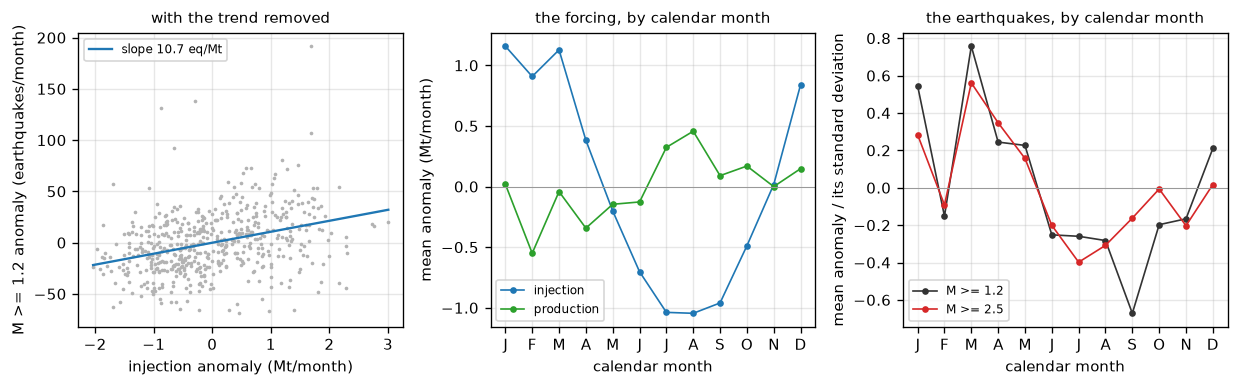

In [7]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10.4, 3.3))
b, se, _ = res_a["n"]
a1.plot(a.injection, a.n, "o", ms=2.2, mfc="0.7", mec="none")
xs = np.linspace(a.injection.min(), a.injection.max(), 50)
a1.plot(xs, b[0] + b[1] * xs, "C0-", lw=1.4, label=f"slope {b[1]:.1f} eq/Mt")
a1.set_xlabel("injection anomaly (Mt/month)"); a1.set_ylabel("M >= 1.2 anomaly (earthquakes/month)")
a1.legend(fontsize=7, loc="upper left"); a1.set_title("with the trend removed", fontsize=9)

cycle = a.groupby(a.index.month)[["injection", "production", "n", "n25"]].mean()
months = list(range(1, 13))
for col, colour in (("injection", "C0"), ("production", "C2")):          # the forcing, in its units
    a2.plot(months, cycle[col], "o-", ms=3, lw=1.0, color=colour, label=col)
a2.set_ylabel("mean anomaly (Mt/month)"); a2.set_title("the forcing, by calendar month", fontsize=9)
for col, colour, lab in (("n", "0.2", "M >= 1.2"), ("n25", "C3", "M >= 2.5")):   # counts differ in size
    a3.plot(months, cycle[col] / a[col].std(), "o-", ms=3, lw=1.0, color=colour, label=lab)
a3.set_ylabel("mean anomaly / its standard deviation")
a3.set_title("the earthquakes, by calendar month", fontsize=9)
for ax in (a2, a3):
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_xticks(months); ax.set_xticklabels(list("JFMAMJJASOND")); ax.set_xlabel("calendar month")
    ax.legend(fontsize=7, loc="lower left")
fig.tight_layout(); plt.show()


With the trend removed, the M ≥ 1.2 anomaly moves with the injection anomaly at several standard
errors, and so does the M ≥ 2.5 anomaly, at a magnitude § 4.7 shows the regional network was already
detecting before the borehole network arrived. The production anomaly does not behave the same way at
the two thresholds: it is between two and three standard errors from zero at M ≥ 1.2 and within one at
M ≥ 2.5. Both numbers are printed above.

What this establishes is shared timing, not mechanism (§ 10.6 of the project notebook): the rate
rises and falls with the injection season. It is also not a test of Eberhart-Phillips & Oppenheimer
(1984). They cross-correlated monthly counts with injection for the wells they studied, over
1975–1982; this fit uses field-wide totals over four decades with the trend removed. Nearly every
choice differs, so neither result is a measurement of the other.


### B.5 · What the interval assumed

Every standard error above rests on the first line of A.3: that the errors are **independent**, which
is what turned a product of densities into a sum. The seismicity of this field is almost entirely swarms (§ 9.4), so a month
with more events than the model predicts may be followed by another. That is a claim about the
residuals of B.4, and it can be measured — against the same statistic on the residuals shuffled into a
random order, which is what independent months would look like.


In [8]:
b, se_a, r = res_a["n"]
ac1 = np.corrcoef(r[:-1], r[1:])[0, 1]
rng_s = np.random.default_rng(207)
shuffled = [abs(np.corrcoef(s_[:-1], s_[1:])[0, 1]) for s_ in (rng_s.permutation(r) for _ in range(1000))]
print(f"lag-1 autocorrelation of the B.4 residuals (M >= 1.2): {ac1:+.2f}")
print(f"  95% of 1000 shuffles of the same residuals fall within +/-{np.percentile(shuffled, 95):.2f}")


lag-1 autocorrelation of the B.4 residuals (M >= 1.2): +0.33
  95% of 1000 shuffles of the same residuals fall within +/-0.09


**Exercise 4.** The standard error in B.4 treats each month as an independent draw. A **moving-block
bootstrap** does not: it resamples contiguous runs of months, so whatever correlation lives inside a
run is carried along intact.

Refit the M ≥ 1.2 anomaly regression of B.4 on resamples built from blocks of 1, 3, 6, 12 and 24
months, 400 resamples each, and store the spread of the injection slope in a dictionary `boot_se`
keyed by block length. Predict first what the one-month block should come close to, and why.


In [9]:
rng_b = np.random.default_rng(207)
Xa = np.column_stack([np.ones(len(a)), a.injection.values, a.production.values])
ya = a.n.values.astype(float)


def block_bootstrap(L, reps=400):
    """Spread of the injection slope when contiguous runs of L months are resampled."""
    k = int(np.ceil(len(ya) / L))
    slopes = []
    for _ in range(reps):
        starts = rng_b.integers(0, len(ya) - L + 1, k)
        idx = np.concatenate([np.arange(s0, s0 + L) for s0 in starts])[:len(ya)]
        slopes.append(np.linalg.lstsq(Xa[idx], ya[idx], rcond=None)[0][1])
    return np.std(slopes)


boot_se = {L: block_bootstrap(L) for L in (1, 3, 6, 12, 24)}
print(f"standard error of the injection slope, from the formula: {se_a[1]:.2f}")
for L, s_ in boot_se.items():
    print(f"  moving-block bootstrap, {L:2d}-month blocks: {s_:.2f}   ({s_ / se_a[1]:.1f}x)")


standard error of the injection slope, from the formula: 1.32
  moving-block bootstrap,  1-month blocks: 1.58   (1.2x)
  moving-block bootstrap,  3-month blocks: 1.59   (1.2x)
  moving-block bootstrap,  6-month blocks: 1.49   (1.1x)
  moving-block bootstrap, 12-month blocks: 2.03   (1.5x)
  moving-block bootstrap, 24-month blocks: 2.35   (1.8x)


In [10]:
# ── Self-check for Exercise 4 ──
if "boot_se" not in globals() or not {1, 24} <= set(boot_se):
    print("Exercise 4 has not stored boot_se[1] and boot_se[24] yet")
else:
    one, long_ = boot_se[1] / se_a[1], boot_se[24] / boot_se[1]
    print(f"1-month blocks / formula      = {one:.2f}   expected 0.8 to 1.4")
    print(f"24-month / 1-month blocks     = {long_:.2f}   expected above 1.2")
    print(f"injection slope / 24-month se = {b[1] / boot_se[24]:.1f}")
    assert 0.8 < one < 1.4 and long_ > 1.2, "is each block a contiguous run of months, and is L used?"
    print("✓ Exercise 4: one-month blocks sit near the formula, and two-year blocks are wider")


1-month blocks / formula      = 1.20   expected 0.8 to 1.4
24-month / 1-month blocks     = 1.50   expected above 1.2
injection slope / 24-month se = 4.5
✓ Exercise 4: one-month blocks sit near the formula, and two-year blocks are wider


The one-month block resamples months independently of one another, and it lands near the formula.
Blocks that keep a year or two of consecutive months together give a wider spread, and that wider figure
is the one that belongs beside the slope of B.4; the last line of the self-check divides the slope by
the two-year figure.


## Part C · The b-value under rising and falling injection

The *b*-value is the slope of the frequency–magnitude distribution, $\log_{10}N(\ge M) = a - bM$: how
many small earthquakes there are for each large one. Leptokaropoulos & Staszek (2018) grouped the seismicity of the northwest Geysers into
periods of increasing and decreasing injection rate and report $b = 1.18 \pm 0.06$ under increasing
injection against $1.10 \pm 0.05$ under decreasing injection, from 1121 events, a difference they find
significant at the 0.05 level.

This part asks the same question of the whole field window, in the order the session has followed:
first a known difference **planted in the real catalogue**, to find out whether one of that size can be
resolved with these data at all; then the same function on the catalogue as it is, where there is no
truth to compare with. The independent check is the same as in Part B: whether a month is one of rising
or falling injection is read from the CalGEM record, not from the catalogue.


### C.1 · The estimator, and where independence enters

A.8 derived the maximum-likelihood rate of an exponential variable: $\hat\beta = 1/(\bar x - x_{\min})$
with standard error $\hat\beta/\sqrt n$. Above a completeness magnitude $M_c$, the Gutenberg–Richter law
makes $M - M_c$ exactly such a variable, with $\beta = b\ln 10$, so the same result is the *b*-value:

1. $\hat b = \hat\beta/\ln 10 = \log_{10}e\,/\,(\bar M - M_c)$ — the estimator § 9.3 of the project
   notebook calls Aki's, needing only the mean magnitude.
2. $b$ is a fixed multiple of $\beta$, so its standard error is the same multiple: $\sigma_b = b/\sqrt n$.
3. The difference of two estimates from separate sets of events is a linear function of them with
   coefficients $(1, -1)$, so by A.5's rule its variance is $\sigma_{b,1}^2 + \sigma_{b,2}^2$ when the two
   are independent.

The likelihood A.8 maximised was a **product** over events, and it is a product only because the events
were assumed independent. The $n$ in $b/\sqrt n$ counts events; C.4 measures what that assumption buys.


In [11]:
# ── Checkpoint 3 ── run this if you are behind or something broke ──
# Part C needs the field-window catalogue and the CalGEM series that B.1 loaded.
import pandas as pd
from geysers_data import catalog, production, FIELD
if "field" not in globals() or "prod" not in globals():
    cat = catalog()
    field = cat[cat.longitude.between(FIELD[0], FIELD[1])
                & cat.latitude.between(FIELD[2], FIELD[3])].sort_values("time")
    prod = production()
print(f"{len(field):,} earthquakes in the field window; CalGEM {prod.index[0]:%Y-%m} to {prod.index[-1]:%Y-%m}")


403,475 earthquakes in the field window; CalGEM 1969-01 to 2026-07


### C.2 · A cut that holds in every year

$\hat b$ is only the Gutenberg–Richter slope above a magnitude at which the catalogue is complete, and
§ 4.7 of the project notebook showed that magnitude moving over the record. Estimate it year by year
with maximum curvature — the modal 0.1-magnitude bin plus 0.2, as in § 9.3 — and take the largest
yearly value, so that one cut serves every year. § 9.3 notes that maximum curvature under-estimates
completeness where the roll-off below it is gradual, so this cut is the least that can be defended.


In [12]:
def mc_maxc(m, bump=0.2):
    """Completeness magnitude by maximum curvature: the modal 0.1 bin, plus a fixed correction."""
    v, c = np.unique(np.round(m, 1), return_counts=True)
    return v[c.argmax()] + bump


YEARS = (1981, 2025)
span = field[field.time.dt.year.between(*YEARS)]
mc_year = span.groupby(span.time.dt.year).mag.apply(lambda m: mc_maxc(m.values)).round(1)
MC = float(mc_year.max())
print(f"yearly Mc by maximum curvature, {YEARS[0]}-{YEARS[1]}: {mc_year.min():.1f} to {MC:.1f}")
print(f"years above M 1.2: {[int(y) for y in mc_year[mc_year > 1.2].index]}")
print(f"the cut used below: M >= {MC:.1f}")

mags = span.mag[span.mag >= MC].values
print(f"\n{len(mags):,} events at or above M {MC:.1f}")
print(f"distinct magnitude values: {pd.Series(mags).round(2).nunique()};  "
      f"on a 0.1 grid: {100 * np.mean(np.abs(mags * 10 - np.round(mags * 10)) < 1e-6):.1f} %")
print("  -> reported to 0.01, not binned, so no binning correction (project notebook, section 9.4)")


yearly Mc by maximum curvature, 1981-2025: 0.6 to 1.4
years above M 1.2: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006]
the cut used below: M >= 1.4

51,345 events at or above M 1.4
distinct magnitude values: 289;  on a 0.1 grid: 10.7 %
  -> reported to 0.01, not binned, so no binning correction (project notebook, section 9.4)


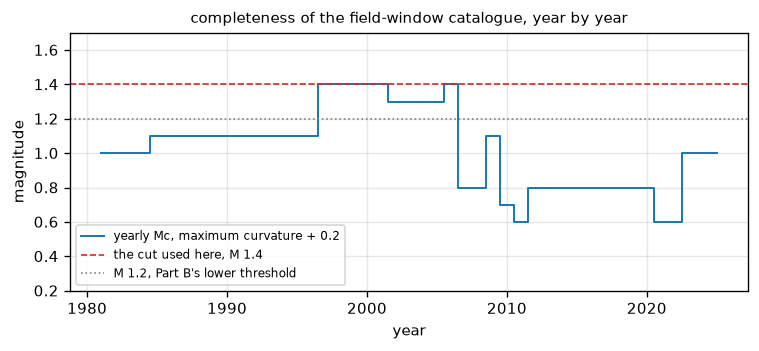

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.step(mc_year.index, mc_year.values, where="mid", color="C0", lw=1.2,
        label="yearly Mc, maximum curvature + 0.2")
ax.axhline(MC, color="C3", ls="--", lw=1.0, label=f"the cut used here, M {MC:.1f}")
ax.axhline(1.2, color="0.5", ls=":", lw=1.0, label="M 1.2, Part B's lower threshold")
ax.set_ylim(0.2, 1.7); ax.set_xlabel("year"); ax.set_ylabel("magnitude")
ax.legend(fontsize=7, loc="lower left")
ax.set_title("completeness of the field-window catalogue, year by year", fontsize=9)
fig.tight_layout(); plt.show()


The magnitudes are a mixture of scales, overwhelmingly coda duration below about magnitude 3 (§ 9.4),
and the planted test in Exercise 5 runs on that mixture as it is.

### C.3 · Rising and falling injection, from the CalGEM record

Leptokaropoulos & Staszek relate *b* to the **slope** of the injection rate. At the only resolution
CalGEM provides, a month is labelled *rising* when the field injected more than in the month before, and
*falling* otherwise.


In [14]:
rising = prod.injection.diff() > 0                  # this month injected more than the one before
g = span[span.mag >= MC].copy()
g["month"] = g.time.dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
g["rising"] = g.month.map(rising).astype(bool)
g["year"] = g.time.dt.year
LS2018 = dict(b_rise=1.18, se_rise=0.06, b_fall=1.10, se_fall=0.05, n=1121)   # their abstract


def b_value(m, mc=MC):
    """The A.8 estimate as a b-value: log10(e) / (mean magnitude - Mc)."""
    return np.log10(np.e) / (np.mean(m) - mc)


def b_split(events):
    """b under rising and under falling injection, their difference, and b/sqrt(n) for each."""
    up, down = events.mag[events.rising].values, events.mag[~events.rising].values
    b_up, b_down = b_value(up), b_value(down)
    return dict(b_rise=b_up, b_fall=b_down, n_rise=len(up), n_fall=len(down), diff=b_up - b_down,
                se_diff=np.hypot(b_up / np.sqrt(len(up)), b_down / np.sqrt(len(down))))


field_split = b_split(g)                            # printed in C.4, beside the planted catalogue
print(f"months: {g[g.rising].month.nunique()} rising, {g[~g.rising].month.nunique()} falling;  events: "
      f"{field_split['n_rise']:,} in rising months, {field_split['n_fall']:,} in falling months")
print(f"\nLeptokaropoulos & Staszek (2018), northwest Geysers, {LS2018['n']} events: "
      f"{LS2018['b_rise']:.2f} +/- {LS2018['se_rise']:.2f} rising, {LS2018['b_fall']:.2f} +/- "
      f"{LS2018['se_fall']:.2f} falling, difference {LS2018['b_rise'] - LS2018['b_fall']:+.2f}")


months: 259 rising, 281 falling;  events: 25,024 in rising months, 26,321 in falling months

Leptokaropoulos & Staszek (2018), northwest Geysers, 1121 events: 1.18 +/- 0.06 rising, 1.10 +/- 0.05 falling, difference +0.08


**Exercise 5 · Plant a known difference in the real catalogue.** On field data the true difference is
unknown, so no difference computed from the catalogue can be checked. A difference can be *made*
known, by thinning.

1. Let $x = M - M_c$ be exponential with rate $\beta$, density $\beta e^{-\beta x}$.
2. Keep each event independently with probability $e^{-\Delta\beta\,x}$, which is at most 1.
3. The kept events have density proportional to $\beta e^{-\beta x}\,e^{-\Delta\beta\,x} \propto
   e^{-(\beta+\Delta\beta)x}$: still exponential, now with rate $\beta + \Delta\beta$.
4. Since $b = \beta/\ln 10$, the *b*-value of the kept events is larger by $\Delta b = \Delta\beta/\ln 10$.

Thin only the **rising** months, with $\Delta b$ equal to the published difference, and report how far
`b_split` moves the rising-month *b*-value: store it as `recovered`, and the thinned catalogue as
`planted`. The generator departs from the estimator's assumption in the way that matters here: steps
1–4 assume an exponential sample, and the magnitudes being thinned are the real mixture of scales, so
how close the recovered step comes to the planted one measures the estimator on this catalogue rather
than on an ideal one.


In [15]:
PLANT = LS2018["b_rise"] - LS2018["b_fall"]           # the size of the published difference
rng_c = np.random.default_rng(207)
keep = (~g.rising.values) | (rng_c.random(len(g)) < np.exp(-PLANT * np.log(10) * (g.mag.values - MC)))
planted = g[keep]
planted_split = b_split(planted)
recovered = planted_split["b_rise"] - field_split["b_rise"]

print(f"planted step in b under rising injection: {PLANT:+.3f}")
print(f"rising-month events kept: {keep[g.rising.values].mean():.1%}")
print(f"recovered step: {recovered:+.3f}")
print(f"planted catalogue, rising - falling: {planted_split['diff']:+.3f} +/- {planted_split['se_diff']:.3f}")


planted step in b under rising injection: +0.080
rising-month events kept: 93.2%
recovered step: +0.073
planted catalogue, rising - falling: +0.058 +/- 0.010


In [16]:
# ── Self-check for Exercise 5 ──
if "recovered" not in globals() or "planted" not in globals():
    print("Exercise 5 has not stored recovered and planted yet")
else:
    step = LS2018["b_rise"] - LS2018["b_fall"]
    moved = b_split(planted)
    d_fall, d_diff = moved["b_fall"] - field_split["b_fall"], moved["diff"] - field_split["diff"]
    print(f"planted {step:+.2f}:  rising-month b moved {recovered:+.3f},  falling-month b moved "
          f"{d_fall:+.3f},  rising - falling moved {d_diff:+.3f}")
    assert abs(recovered - step) < 0.02 and abs(d_fall) < 0.005 and abs(d_diff - step) < 0.02, \
        "thin the rising months only, keeping each event with probability exp(-delta_b ln10 (M - Mc))"
    print("✓ Exercise 5: the planted step moved only the rising months, by about its planted size")


planted +0.08:  rising-month b moved +0.073,  falling-month b moved +0.000,  rising - falling moved +0.073
✓ Exercise 5: the planted step moved only the rising months, by about its planted size


In [17]:
# ── Checkpoint 4 ── run this if you are behind or something broke ──
# C.4 compares the field catalogue with the planted one; this rebuilds the planted one.
PLANT_CP = LS2018["b_rise"] - LS2018["b_fall"]
_r6 = np.random.default_rng(207)
_keep6 = (~g.rising.values) | (_r6.random(len(g)) < np.exp(-PLANT_CP * np.log(10) * (g.mag.values - MC)))
planted_cp = g[_keep6]
print(f"planted catalogue: {len(planted_cp):,} events, rising - falling {b_split(planted_cp)['diff']:+.3f}")


planted catalogue: 49,632 events, rising - falling +0.058


### C.4 · What independence was buying

Resample **whole calendar years** with replacement. Each year keeps its swarms, its own rising and
falling months, and whatever else it shares internally, so dependence inside a year survives into the
spread. Do it for the single field-wide *b* and for the rising-minus-falling difference, on the field
catalogue and on the planted one, and set each against $b/\sqrt n$.


In [18]:
def year_bootstrap(events, reps=400, seed=207):
    """Spread of the single b and of the rising-falling difference when whole years are resampled."""
    r_ = np.random.default_rng(seed)
    blocks = [(grp.mag.values, grp.rising.values) for _, grp in events.groupby("year")]
    single, diff = [], []
    for _ in range(reps):
        pick = r_.integers(0, len(blocks), len(blocks))
        m_ = np.concatenate([blocks[i][0] for i in pick])
        up = np.concatenate([blocks[i][1] for i in pick])
        single.append(b_value(m_))
        diff.append(b_value(m_[up]) - b_value(m_[~up]))
    return np.array(single), np.array(diff)


print(f"{g.year.nunique()} calendar years to resample, {g.year.min()} to {g.year.max()}")


45 calendar years to resample, 1981 to 2025


In [19]:
summary = []
for label, events in (("field", g), ("planted", planted_cp)):
    single, diff = year_bootstrap(events)
    sp = b_split(events)
    b_all = b_value(events.mag.values)
    lo, hi = np.percentile(diff, [2.5, 97.5])
    print(f"{label} catalogue ({len(events):,} events, {events.year.nunique()} years)")
    print(f"  b = {sp['b_rise']:.3f} in rising months (n = {sp['n_rise']:,}), "
          f"{sp['b_fall']:.3f} in falling months (n = {sp['n_fall']:,})")
    print(f"  single b = {b_all:.3f}:  b/sqrt(n) {b_all / np.sqrt(len(events)):.4f},  "
          f"year blocks {single.std():.4f}  ({single.std() / (b_all / np.sqrt(len(events))):.1f}x)")
    print(f"  rising - falling = {sp['diff']:+.3f}:  formula {sp['se_diff']:.4f},  "
          f"year blocks {diff.std():.4f}  ({diff.std() / sp['se_diff']:.1f}x);  "
          f"95% year-block interval [{lo:+.3f}, {hi:+.3f}]")
    summary.append(dict(catalogue=label, mc=MC, first_year=YEARS[0], last_year=YEARS[1],
                        b=b_all, n=len(events), b_rise=sp["b_rise"], n_rise=sp["n_rise"],
                        b_fall=sp["b_fall"], n_fall=sp["n_fall"], diff=sp["diff"],
                        se_diff_formula=sp["se_diff"], se_diff_year_blocks=diff.std(),
                        diff_lo95=lo, diff_hi95=hi))


field catalogue (51,345 events, 45 years)
  b = 1.080 in rising months (n = 25,024), 1.095 in falling months (n = 26,321)
  single b = 1.087:  b/sqrt(n) 0.0048,  year blocks 0.0095  (2.0x)
  rising - falling = -0.015:  formula 0.0096,  year blocks 0.0110  (1.1x);  95% year-block interval [-0.035, +0.006]
planted catalogue (49,632 events, 45 years)
  b = 1.152 in rising months (n = 23,311), 1.095 in falling months (n = 26,321)
  single b = 1.121:  b/sqrt(n) 0.0050,  year blocks 0.0093  (1.8x)
  rising - falling = +0.058:  formula 0.0101,  year blocks 0.0116  (1.1x);  95% year-block interval [+0.036, +0.079]


In [20]:
by_year = g.groupby(["year", "rising"]).mag.apply(lambda m: b_value(m.values)).unstack()
print(f"\ncorrelation between the yearly b of rising and of falling months: "
      f"{by_year[True].corr(by_year[False]):+.2f}  over {len(by_year)} years")

# The artifact this part leaves for the project.
pd.DataFrame(summary).round(4).to_csv("my_b_injection.csv", index=False)
print("wrote my_b_injection.csv")



correlation between the yearly b of rising and of falling months: +0.56  over 45 years
wrote my_b_injection.csv


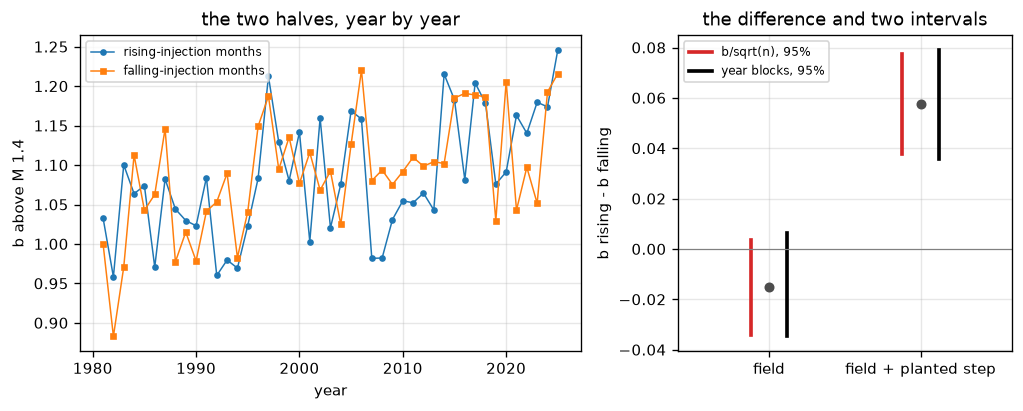

In [21]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.5), gridspec_kw=dict(width_ratios=[1.5, 1]))
a1.plot(by_year.index, by_year[True], "o-", ms=3, lw=0.9, color="C0", label="rising-injection months")
a1.plot(by_year.index, by_year[False], "s-", ms=3, lw=0.9, color="C1", label="falling-injection months")
a1.set_xlabel("year"); a1.set_ylabel(f"b above M {MC:.1f}")
a1.legend(fontsize=7, loc="upper left"); a1.set_title("the two halves, year by year")

for k, row in enumerate(summary):
    for dx, (half, colour, lab) in enumerate(((1.96 * row["se_diff_formula"], "C3", "b/sqrt(n), 95%"),
                                              (None, "k", "year blocks, 95%"))):
        lo_, hi_ = ((row["diff"] - half, row["diff"] + half) if half is not None
                    else (row["diff_lo95"], row["diff_hi95"]))
        a2.plot([k + 0.12 * (2 * dx - 1)] * 2, [lo_, hi_], "-", color=colour, lw=2.2,
                label=lab if k == 0 else None)
    a2.plot(k, row["diff"], "o", color="0.3", ms=5)
a2.axhline(0, color="0.5", lw=0.7)
a2.set_xticks([0, 1]); a2.set_xticklabels(["field", "field + planted step"])
a2.set_xlim(-0.6, 1.6); a2.set_ylabel("b rising - b falling")
a2.legend(fontsize=7, loc="upper left"); a2.set_title("the difference and two intervals")
fig.tight_layout(); plt.show()


Resampling years roughly doubles the interval on the single field-wide *b*, and hardly changes the
interval on the difference. The printed correlation is the reason that can be checked: the yearly
*b*-values of rising and falling months rise and fall together, so whatever moves *b* from one year to
the next moves both halves, and a difference taken within the same years cancels most of it. A b-value
compared between different eras gets no such cancellation.

Taken together with Exercise 5, the two catalogues say different things. The planted step, the size of
the published difference, stands well clear of zero under either interval. The field difference is
small, of the opposite sign to the published one, and its year-block interval includes zero.

### C.5 · Against the published result

Before reading the field number as a test of Leptokaropoulos & Staszek (2018), list what differs.
Their events are from the **northwest** of the field and number 1121; these are the whole field window,
some tens of thousands. They relate *b* to injection at lags of up to about fifteen days, which needs
injection data finer than a month; CalGEM here is field-wide and monthly (§ 2.6). Their completeness
cut, period and estimator are not reproduced here. With that many differences the field number is not
a measurement of their result. In this catalogue at this cut, a planted difference of their size stood
clear of zero under both intervals, and the difference measured on the catalogue as it is did not.


## Takeaways

### Machine learning

- A column left out of a design moves the coefficient of any column that moves with it: the production
  slope went from within one standard error of zero to several once calendar time was a column, while
  the inflation factors stayed small.
- On field data a method can still be tested against a truth planted in the data themselves: a
  difference in b imposed by thinning the real catalogue came back close to its planted size.
- A standard error computed under independence is a statement about resampling independent rows;
  resampling contiguous blocks of months widened the interval on the injection slope, and resampling
  years widened the single b-value's interval while leaving the within-year difference nearly unchanged.

### Seismology

- At The Geysers the monthly earthquake rate carries the annual cycle of the CalGEM injection record
  at both magnitude thresholds once the trend is removed, consistent with the strong seasonal
  fluctuation of the background rate after 2003 that Trugman et al. (2016) report.
- The field-wide b-value varies from year to year by more than b/√n allows — resampling whole years
  doubled its interval — consistent with the significant temporal variations in b that Trugman et al.
  (2016) report.
- The difference in b between increasing and decreasing injection that Leptokaropoulos & Staszek (2018)
  report in the northwest of the field is not found field-wide at monthly resolution, where the measured
  difference is small and of the opposite sign, although a planted difference of that size was resolved
  in the same catalogue.